### Cell 1


In [9]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CONFIG = {
    "project_root": Path(".."),
    "raw_data_path": Path("../data/raw/Dry_Bean_Dataset.xlsx"),
    "processed_data_dir": Path("../data/processed"),
    "results_dir": Path("../results/01_data_understanding"),
    "plots_dir": Path("../plots/01_data_understanding"),
    "target_column": "Class",
    "random_seed": RANDOM_SEED,
}

for folder in [
    CONFIG["processed_data_dir"],
    CONFIG["results_dir"],
    CONFIG["plots_dir"],
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Notebook setup completed.")
print(f"Raw data path: {CONFIG['raw_data_path']}")
print(f"Results will be saved in: {CONFIG['results_dir']}")
print(f"Plots will be saved in: {CONFIG['plots_dir']}")

Notebook setup completed.
Raw data path: ../data/raw/Dry_Bean_Dataset.xlsx
Results will be saved in: ../results/01_data_understanding
Plots will be saved in: ../plots/01_data_understanding


### Cell 2 Load the dataset

The Dry Bean dataset is usually stored as an Excel file.  
We will load the dataset and check whether the expected target column exists.

In [10]:
def load_data(file_path: Path, target_column: str) -> pd.DataFrame:
    """
    Load the Dry Bean dataset from an Excel file.
    """
    if not file_path.exists():
        raise FileNotFoundError(
            f"Dataset not found at {file_path}. "
            "Please place Dry_Bean_Dataset.xlsx inside data/raw/."
        )

    df = pd.read_excel(file_path)

    if target_column not in df.columns:
        raise ValueError(
            f"Target column '{target_column}' not found. "
            f"Available columns are: {list(df.columns)}"
        )

    return df


df = load_data(CONFIG["raw_data_path"], CONFIG["target_column"])

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset loaded successfully.
Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### Cell 3 Basic dataset information

In [11]:
print("Dataset shape")
print("-" * 40)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names")
print("-" * 40)
for col in df.columns:
    print(col)

print("\nData types")
print("-" * 40)
display(df.dtypes)

Dataset shape
----------------------------------------
Rows: 13611
Columns: 17

Column names
----------------------------------------
Area
Perimeter
MajorAxisLength
MinorAxisLength
AspectRation
Eccentricity
ConvexArea
EquivDiameter
Extent
Solidity
roundness
Compactness
ShapeFactor1
ShapeFactor2
ShapeFactor3
ShapeFactor4
Class

Data types
----------------------------------------


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

### Cell 4 

In [12]:
target_column = CONFIG["target_column"]

feature_columns = [col for col in df.columns if col != target_column]

X = df[feature_columns]
y = df[target_column]

print(f"Number of features: {len(feature_columns)}")
print(f"Target column: {target_column}")

print("\nFeature columns:")
for col in feature_columns:
    print(f"- {col}")

print("\nTarget classes:")
print(sorted(y.unique()))

Number of features: 16
Target column: Class

Feature columns:
- Area
- Perimeter
- MajorAxisLength
- MinorAxisLength
- AspectRation
- Eccentricity
- ConvexArea
- EquivDiameter
- Extent
- Solidity
- roundness
- Compactness
- ShapeFactor1
- ShapeFactor2
- ShapeFactor3
- ShapeFactor4

Target classes:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


### Cell 5
Missing value analysis

In [13]:
def analyze_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate missing value count and percentage for each column.
    """
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100

    missing_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    })

    return missing_df.sort_values(by="missing_count", ascending=False)


missing_values_df = analyze_missing_values(df)

display(missing_values_df)

missing_values_path = CONFIG["results_dir"] / "missing_values.csv"
missing_values_df.to_csv(missing_values_path)

print(f"Missing value report saved to: {missing_values_path}")

,missing_count,missing_percentage
Area,0,0.0
Perimeter,0,0.0
MajorAxisLength,0,0.0
MinorAxisLength,0,0.0
AspectRation,0,0.0
Eccentricity,0,0.0
ConvexArea,0,0.0
EquivDiameter,0,0.0
Extent,0,0.0
Solidity,0,0.0


Missing value report saved to: ../results/01_data_understanding/missing_values.csv


### Cell 6 Duplicate row analysis

In [14]:
def analyze_duplicates(df: pd.DataFrame) -> dict:
    """
    Count duplicate rows in the dataset.
    """
    duplicate_count = int(df.duplicated().sum())
    duplicate_percentage = float((duplicate_count / len(df)) * 100)

    return {
        "total_rows": int(len(df)),
        "duplicate_rows": duplicate_count,
        "duplicate_percentage": duplicate_percentage,
    }


duplicate_summary = analyze_duplicates(df)

display(duplicate_summary)

duplicate_path = CONFIG["results_dir"] / "duplicate_summary.json"
with open(duplicate_path, "w") as file:
    json.dump(duplicate_summary, file, indent=4)

print(f"Duplicate summary saved to: {duplicate_path}")

{'total_rows': 13611,
 'duplicate_rows': 68,
 'duplicate_percentage': 0.49959591506869444}

Duplicate summary saved to: ../results/01_data_understanding/duplicate_summary.json


### Cell 7 Class distribution

In [15]:
def get_class_distribution(y: pd.Series) -> pd.DataFrame:
    """
    Calculate class count and class percentage.
    """
    class_counts = y.value_counts().sort_index()
    class_percentages = (class_counts / len(y)) * 100

    class_distribution = pd.DataFrame({
        "class_name": class_counts.index,
        "count": class_counts.values,
        "percentage": class_percentages.values,
    })

    return class_distribution


class_distribution_df = get_class_distribution(y)

display(class_distribution_df)

class_distribution_path = CONFIG["results_dir"] / "class_distribution.csv"
class_distribution_df.to_csv(class_distribution_path, index=False)

print(f"Class distribution saved to: {class_distribution_path}")

,class_name,count,percentage
0,BARBUNYA,1322,9.712732
1,BOMBAY,522,3.835133
2,CALI,1630,11.975608
3,DERMASON,3546,26.052458
4,HOROZ,1928,14.165014
5,SEKER,2027,14.892366
6,SIRA,2636,19.366689


Class distribution saved to: ../results/01_data_understanding/class_distribution.csv


### Cell 8 Class distribution plot


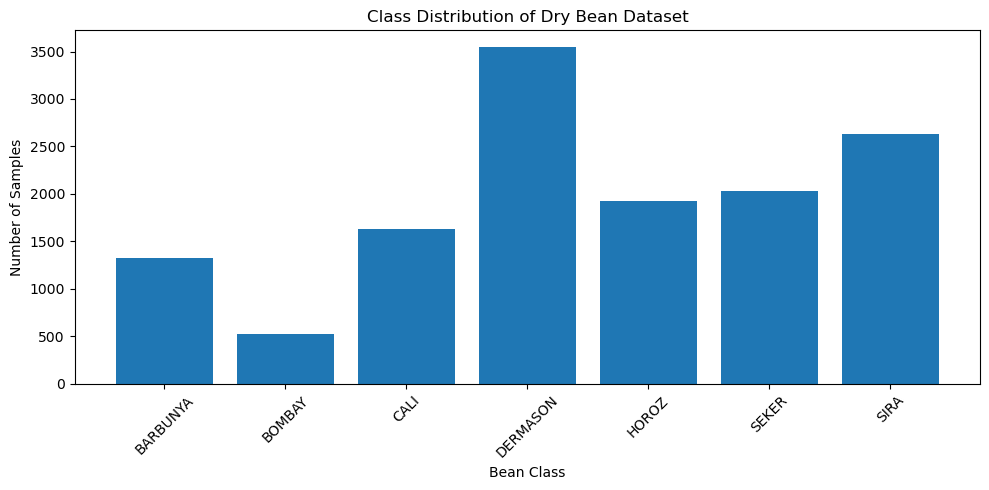

Class distribution plot saved to: ../plots/01_data_understanding/class_distribution.png


In [16]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution_df["class_name"],
    class_distribution_df["count"]
)

plt.title("Class Distribution of Dry Bean Dataset")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()

class_plot_path = CONFIG["plots_dir"] / "class_distribution.png"
plt.savefig(class_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Class distribution plot saved to: {class_plot_path}")

### Cell 9 Descriptive statistics
calculate mean, standard deviation, minimum, maximum, and quartiles for all numerical features <br>
Logistic Regression and MLP need feature scaling <br>
Tree-based models do not require scaling as strongly <br>
SHAP and LIME explanations can be affected by feature scale 

In [17]:
descriptive_stats_df = X.describe().T

display(descriptive_stats_df)

descriptive_stats_path = CONFIG["results_dir"] / "descriptive_statistics.csv"
descriptive_stats_df.to_csv(descriptive_stats_path)

print(f"Descriptive statistics saved to: {descriptive_stats_path}")

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


Descriptive statistics saved to: ../results/01_data_understanding/descriptive_statistics.csv


### Cell 10 Feature distribution plots
StandardScaler for Logistic Regression and MLP

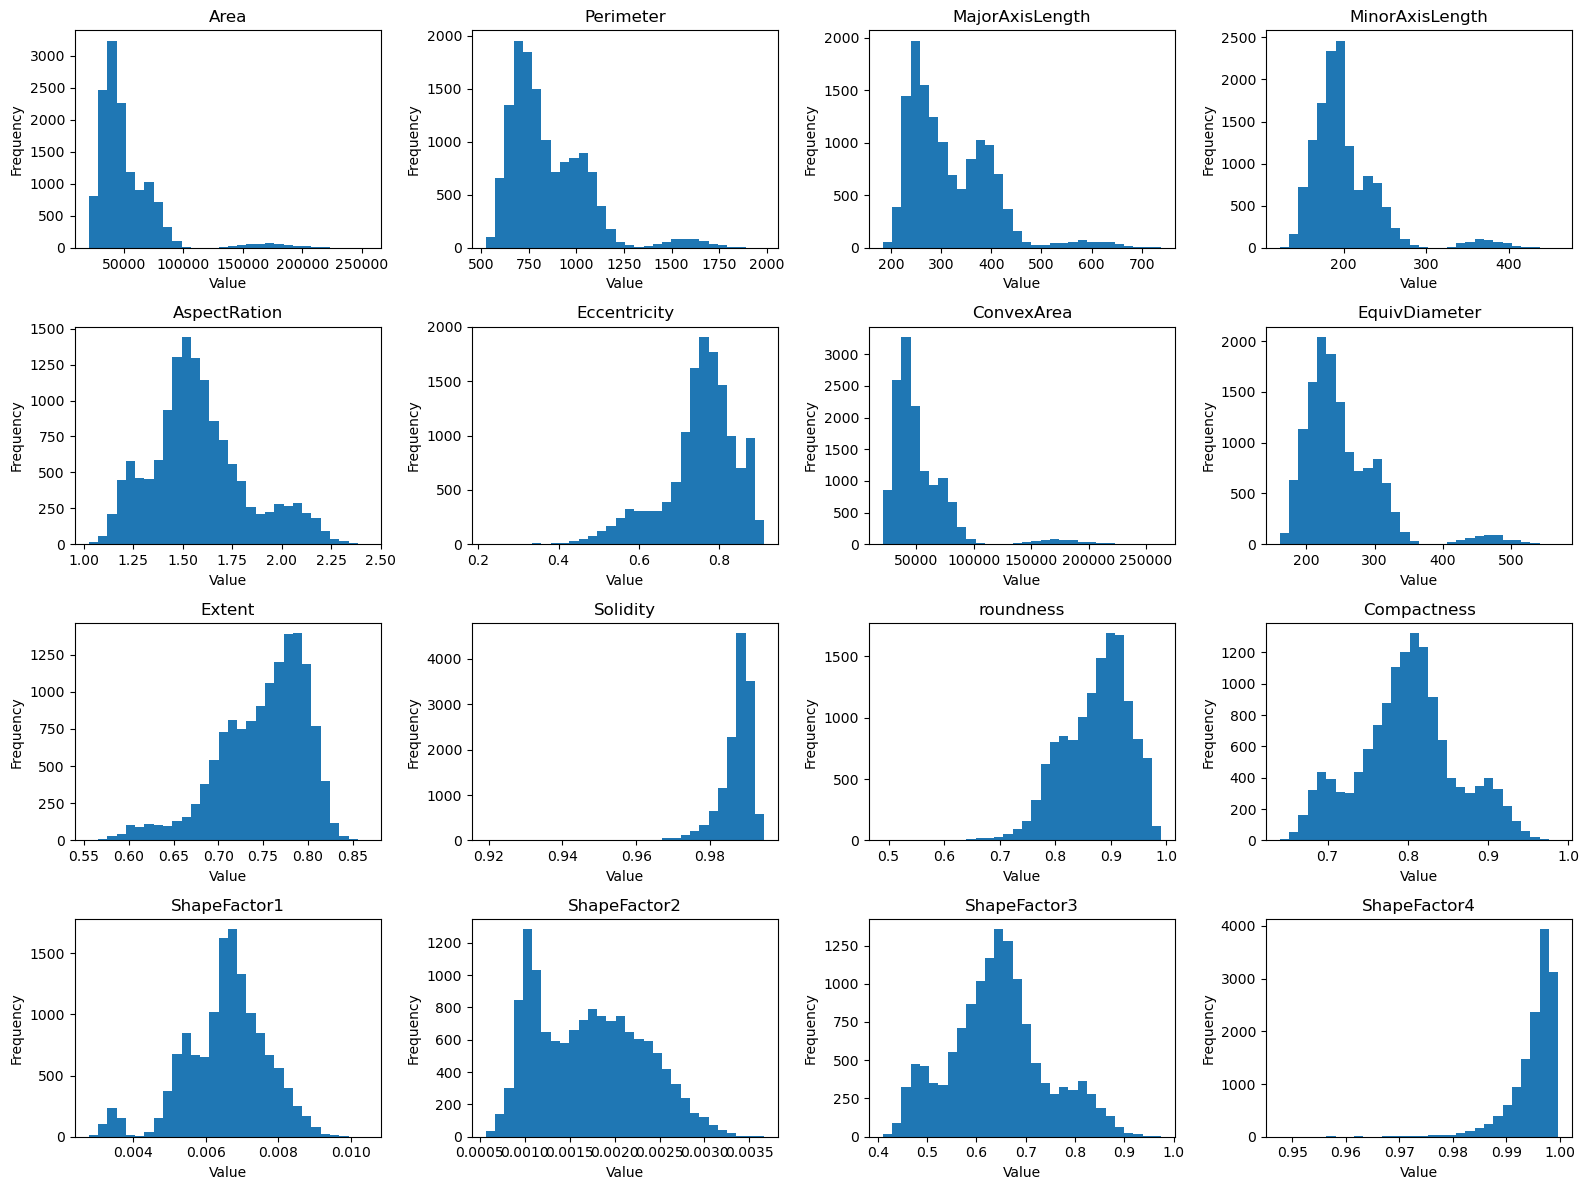

Feature histogram plot saved to: ../plots/01_data_understanding/feature_histograms.png


In [18]:
def plot_feature_histograms(X: pd.DataFrame, save_path: Path) -> None:
    """
    Plot histograms for all feature columns.
    """
    num_features = len(X.columns)
    cols = 4
    rows = int(np.ceil(num_features / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()

    for index, column in enumerate(X.columns):
        axes[index].hist(X[column], bins=30)
        axes[index].set_title(column)
        axes[index].set_xlabel("Value")
        axes[index].set_ylabel("Frequency")

    for index in range(num_features, len(axes)):
        axes[index].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


histogram_path = CONFIG["plots_dir"] / "feature_histograms.png"
plot_feature_histograms(X, histogram_path)

print(f"Feature histogram plot saved to: {histogram_path}")

### Cell 11 Correlation analysis

Correlation analysis helps us understand relationships between features. <br>

If two features are highly correlated, they may provide similar information. <br>
This is important for interpretation because SHAP and LIME explanations may distribute importance across correlated features.

In [19]:
correlation_matrix = X.corr()

display(correlation_matrix)

correlation_path = CONFIG["results_dir"] / "correlation_matrix.csv"
correlation_matrix.to_csv(correlation_path)

print(f"Correlation matrix saved to: {correlation_path}")

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Area,1.000000,0.966722,0.931834,0.951602,0.241735,0.267481,0.999939,0.984968,0.054345,-0.196585,-0.357530,-0.268067,-0.847958,-0.639291,-0.272145,-0.355721
Perimeter,0.966722,1.000000,0.977338,0.913179,0.385276,0.391066,0.967689,0.991380,-0.021160,-0.303970,-0.547647,-0.406857,-0.864623,-0.767592,-0.408435,-0.429310
MajorAxisLength,0.931834,0.977338,1.000000,0.826052,0.550335,0.541972,0.932607,0.961733,-0.078062,-0.284302,-0.596358,-0.568377,-0.773609,-0.859238,-0.568185,-0.482527
MinorAxisLength,0.951602,0.913179,0.826052,1.000000,-0.009161,0.019574,0.951339,0.948539,0.145957,-0.155831,-0.210344,-0.015066,-0.947204,-0.471347,-0.019326,-0.263749
AspectRation,0.241735,0.385276,0.550335,-0.009161,1.000000,0.924293,0.243301,0.303647,-0.370184,-0.267754,-0.766979,-0.987687,0.024593,-0.837841,-0.978592,-0.449264
Eccentricity,0.267481,0.391066,0.541972,0.019574,0.924293,1.000000,0.269255,0.318667,-0.319362,-0.297592,-0.722272,-0.970313,0.019920,-0.860141,-0.981058,-0.449354
ConvexArea,0.999939,0.967689,0.932607,0.951339,0.243301,0.269255,1.000000,0.985226,0.052564,-0.206191,-0.362083,-0.269922,-0.847950,-0.640862,-0.274024,-0.362049
EquivDiameter,0.984968,0.991380,0.961733,0.948539,0.303647,0.318667,0.985226,1.000000,0.028383,-0.231648,-0.435945,-0.327650,-0.892741,-0.713069,-0.330389,-0.392512
Extent,0.054345,-0.021160,-0.078062,0.145957,-0.370184,-0.319362,0.052564,0.028383,1.000000,0.191389,0.344411,0.354212,-0.141616,0.237956,0.347624,0.148502
Solidity,-0.196585,-0.303970,-0.284302,-0.155831,-0.267754,-0.297592,-0.206191,-0.231648,0.191389,1.000000,0.607150,0.303766,0.153388,0.343559,0.307662,0.702163


Correlation matrix saved to: ../results/01_data_understanding/correlation_matrix.csv


### Cell 12 Correlation heatmap

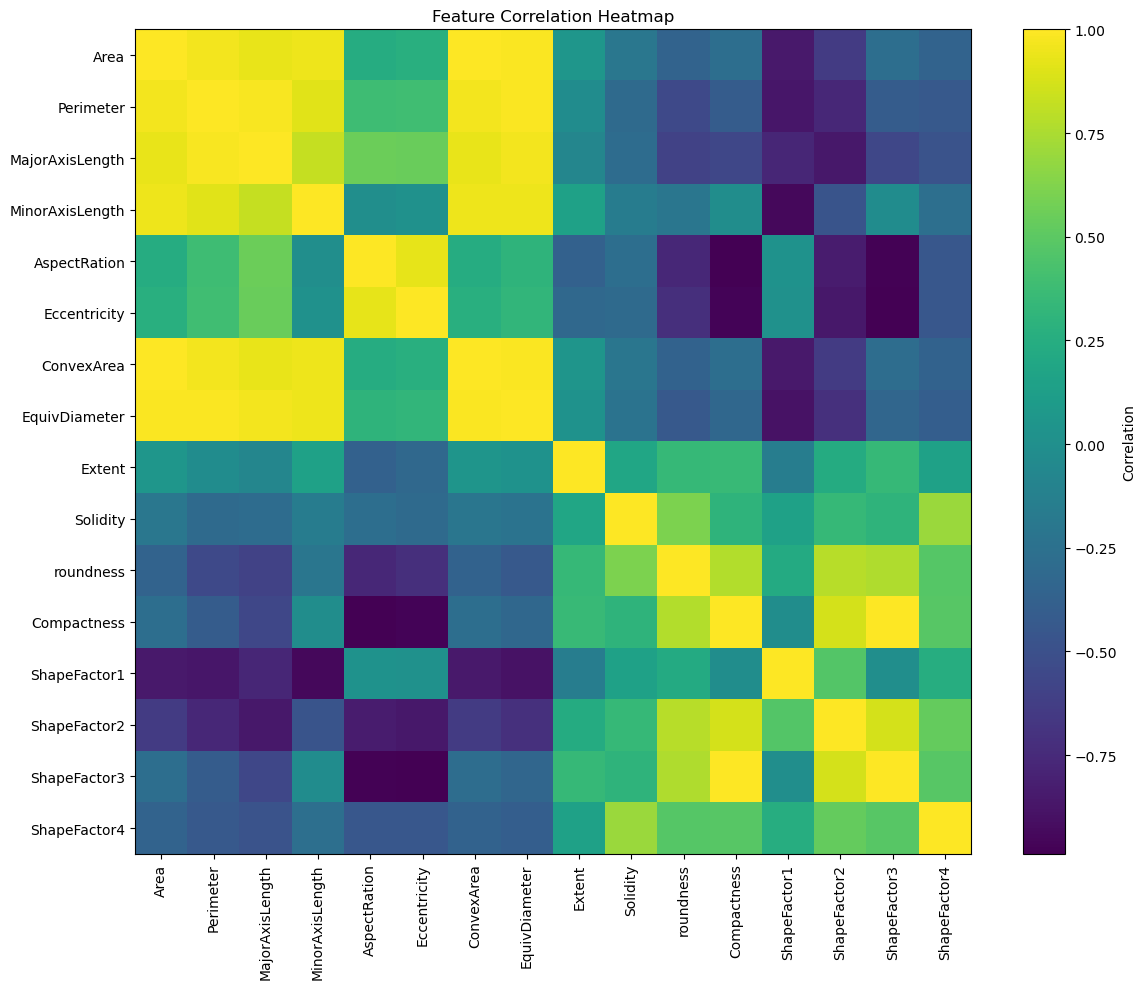

Correlation heatmap saved to: ../plots/01_data_understanding/correlation_heatmap.png


In [20]:
plt.figure(figsize=(12, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=np.arange(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

correlation_plot_path = CONFIG["plots_dir"] / "correlation_heatmap.png"
plt.savefig(correlation_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Correlation heatmap saved to: {correlation_plot_path}")

### Cell 13 Top correlated feature pairs
when features are highly correlated, SHAP and LIME can behave differently.

In [21]:
def get_top_correlations(correlation_matrix: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    """
    Extract top correlated feature pairs without duplicate pairs.
    """
    correlations = []

    columns = correlation_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            feature_1 = columns[i]
            feature_2 = columns[j]
            corr_value = correlation_matrix.loc[feature_1, feature_2]

            correlations.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": corr_value,
                "absolute_correlation": abs(corr_value),
            })

    correlation_pairs_df = pd.DataFrame(correlations)
    correlation_pairs_df = correlation_pairs_df.sort_values(
        by="absolute_correlation",
        ascending=False
    )

    return correlation_pairs_df.head(top_n)


top_correlations_df = get_top_correlations(correlation_matrix, top_n=15)

display(top_correlations_df)

top_correlations_path = CONFIG["results_dir"] / "top_correlations.csv"
top_correlations_df.to_csv(top_correlations_path, index=False)

print(f"Top correlation pairs saved to: {top_correlations_path}")

,feature_1,feature_2,correlation,absolute_correlation
5,Area,ConvexArea,0.999939,0.999939
112,Compactness,ShapeFactor3,0.998686,0.998686
20,Perimeter,EquivDiameter,0.991380,0.991380
60,AspectRation,Compactness,-0.987687,0.987687
75,ConvexArea,EquivDiameter,0.985226,0.985226
6,Area,EquivDiameter,0.984968,0.984968
73,Eccentricity,ShapeFactor3,-0.981058,0.981058
63,AspectRation,ShapeFactor3,-0.978592,0.978592
15,Perimeter,MajorAxisLength,0.977338,0.977338
70,Eccentricity,Compactness,-0.970313,0.970313


Top correlation pairs saved to: ../results/01_data_understanding/top_correlations.csv


### Cell 14 Boxplots for selected important features

In [22]:
selected_features = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "Roundness",
    "Compactness"
]

available_selected_features = [
    feature for feature in selected_features if feature in df.columns
]

print("Selected features available:")
print(available_selected_features)

Selected features available:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Compactness']


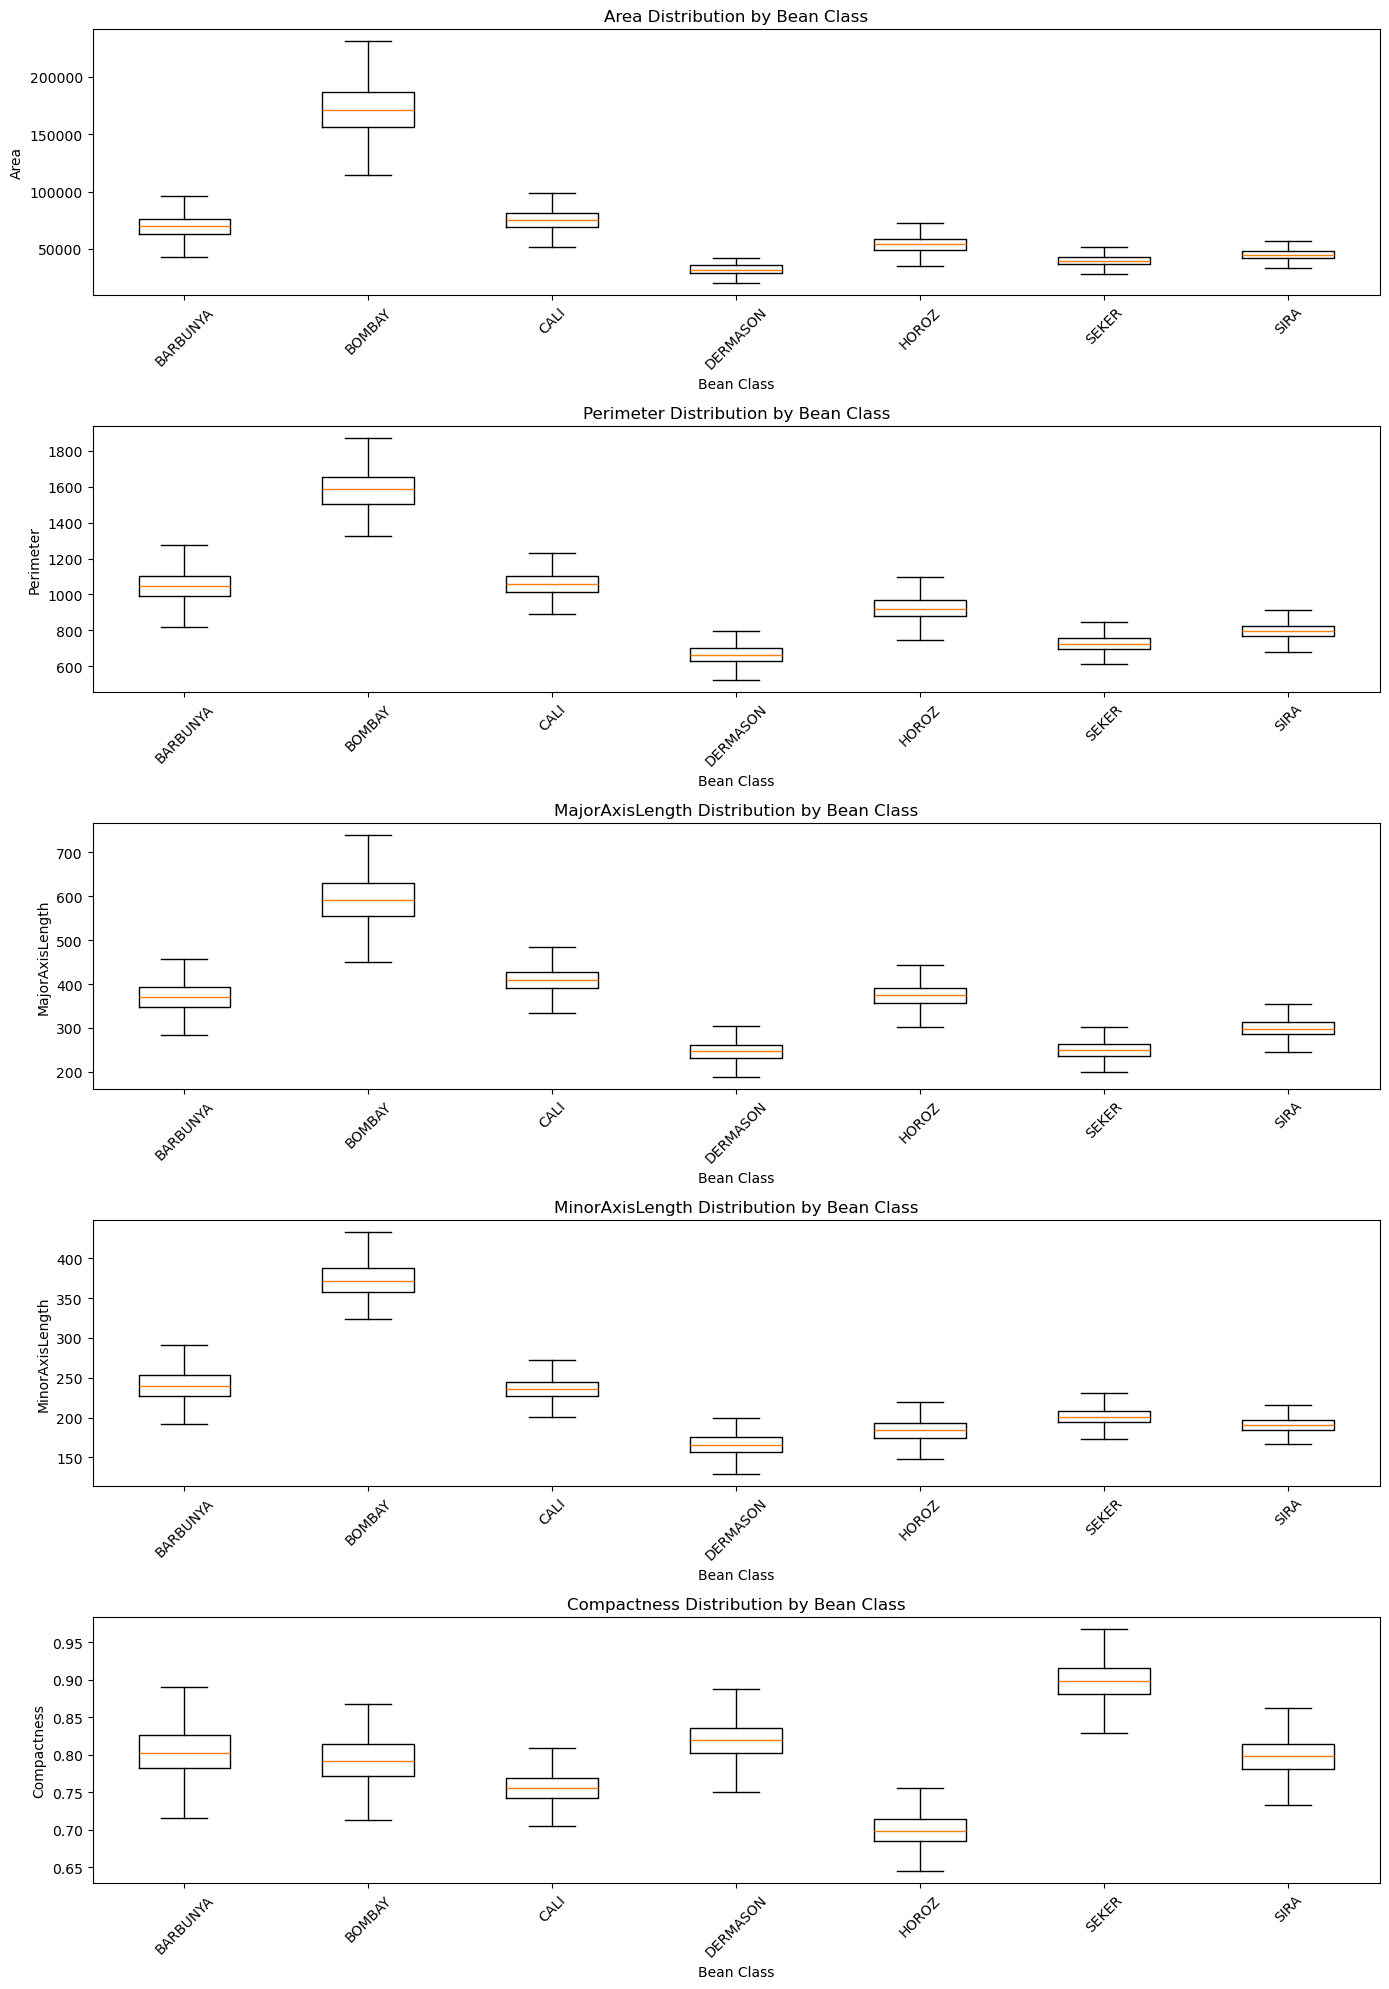

Boxplot figure saved to: ../plots/01_data_understanding/selected_feature_boxplots_by_class.png


In [23]:
def plot_boxplots_by_class(
    df: pd.DataFrame,
    features: list,
    target_column: str,
    save_path: Path
) -> None:
    """
    Plot boxplots for selected features grouped by class.
    """
    num_features = len(features)
    fig, axes = plt.subplots(num_features, 1, figsize=(14, num_features * 4))

    if num_features == 1:
        axes = [axes]

    classes = sorted(df[target_column].unique())

    for ax, feature in zip(axes, features):
        data_by_class = [
            df[df[target_column] == class_name][feature].values
            for class_name in classes
        ]

        ax.boxplot(data_by_class, labels=classes, showfliers=False)
        ax.set_title(f"{feature} Distribution by Bean Class")
        ax.set_xlabel("Bean Class")
        ax.set_ylabel(feature)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


boxplot_path = CONFIG["plots_dir"] / "selected_feature_boxplots_by_class.png"

plot_boxplots_by_class(
    df=df,
    features=available_selected_features,
    target_column=target_column,
    save_path=boxplot_path
)

print(f"Boxplot figure saved to: {boxplot_path}")

### Cell 15. Save an initial clean copy

In [24]:
initial_clean_path = CONFIG["processed_data_dir"] / "dry_bean_initial_clean_copy.csv"

df.to_csv(initial_clean_path, index=False)

print(f"Initial clean copy saved to: {initial_clean_path}")

Initial clean copy saved to: ../data/processed/dry_bean_initial_clean_copy.csv


### Cell 16 Dataset summary

In [25]:
dataset_summary = {
    "dataset_name": "Dry Bean Dataset",
    "total_rows": int(df.shape[0]),
    "total_columns": int(df.shape[1]),
    "number_of_features": int(len(feature_columns)),
    "target_column": target_column,
    "classes": sorted([str(class_name) for class_name in y.unique()]),
    "number_of_classes": int(y.nunique()),
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "random_seed": CONFIG["random_seed"],
}

summary_path = CONFIG["results_dir"] / "dataset_summary.json"

with open(summary_path, "w") as file:
    json.dump(dataset_summary, file, indent=4)

display(dataset_summary)

print(f"Dataset summary saved to: {summary_path}")

{'dataset_name': 'Dry Bean Dataset',
 'total_rows': 13611,
 'total_columns': 17,
 'number_of_features': 16,
 'target_column': 'Class',
 'classes': ['BARBUNYA',
  'BOMBAY',
  'CALI',
  'DERMASON',
  'HOROZ',
  'SEKER',
  'SIRA'],
 'number_of_classes': 7,
 'missing_values_total': 0,
 'duplicate_rows': 68,
 'random_seed': 42}

Dataset summary saved to: ../results/01_data_understanding/dataset_summary.json


In [26]:
print("Initial observations")
print("-" * 60)

print(f"1. The dataset contains {df.shape[0]} samples.")
print(f"2. The dataset contains {len(feature_columns)} input features.")
print(f"3. The target column is '{target_column}'.")
print(f"4. The number of bean classes is {y.nunique()}.")
print(f"5. Total missing values: {df.isnull().sum().sum()}.")
print(f"6. Duplicate rows: {df.duplicated().sum()}.")

most_common_class = class_distribution_df.sort_values(
    by="count",
    ascending=False
).iloc[0]

least_common_class = class_distribution_df.sort_values(
    by="count",
    ascending=True
).iloc[0]

print(
    f"7. The most frequent class is {most_common_class['class_name']} "
    f"with {most_common_class['count']} samples."
)

print(
    f"8. The least frequent class is {least_common_class['class_name']} "
    f"with {least_common_class['count']} samples."
)

print("9. Correlated features should be considered carefully during XAI analysis.")
print("10. Feature scaling will be important for Logistic Regression and MLP.")

Initial observations
------------------------------------------------------------
1. The dataset contains 13611 samples.
2. The dataset contains 16 input features.
3. The target column is 'Class'.
4. The number of bean classes is 7.
5. Total missing values: 0.
6. Duplicate rows: 68.
7. The most frequent class is DERMASON with 3546 samples.
8. The least frequent class is BOMBAY with 522 samples.
9. Correlated features should be considered carefully during XAI analysis.
10. Feature scaling will be important for Logistic Regression and MLP.
